### Create Gaussian Process around dataset

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType


s_type = ServiceType.QR
df = pd.read_csv("../statics/metrics_TSC_EXPLORE.csv")
# 2. Initialize and train
gp = GASK(s_type, show_figures=False)
gp.init_model(df, data_density=1.0)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
INFO:multiscale:train_gp_models took 392 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [2]:
import numpy as np
%load_ext autoreload
%autoreload 2

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})


from agent.components.commons import ServiceVar
from typing import Dict, Tuple



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Test if the global optimizer converges to a nice result

In [11]:
from agent.components.GaussianProcess import get_empirical_variable_bounds
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos_default = slo_lib.get_slo_for_client("experiment-1", "default")
slos_high_perf = slo_lib.get_slo_for_client("experiment-1", "high_perf")
slos_low_cost = slo_lib.get_slo_for_client("experiment-1", "low_cost")
slos_high_quality = slo_lib.get_slo_for_client("experiment-1", "high_quality")

empirical_var_bounds = get_empirical_variable_bounds(gp.training_data)[s_type]
print(empirical_var_bounds)

starting_point = [6.0, 400] + ([1.0] if s_type == ServiceType.CV else [])
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(s_type, slos_default, gp, empirical_var_bounds, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{<ServiceVar.COST: 'cores'>: (np.float64(1.0), np.float64(6.0)), <ServiceVar.QUALITY: 'data_quality'>: (np.int64(101), np.int64(990)), <ServiceVar.PERFORMANCE: 'max_tp'>: (np.float64(14.285714285714286), np.float64(1666.6666666666665))}


[np.float64(1.8690115257492885), np.float64(101.0)]

### Test how much the epsilon should be moved each iteration

In [4]:
import numpy as np

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))

simple_param_bounds = get_empirical_variable_bounds(gp.training_data)[s_type]
del simple_param_bounds[ServiceVar.PERFORMANCE]
simple_param_bounds = list(simple_param_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos_default, gp, simple_param_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos_default, gp, simple_param_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000019
Eps 0.001: Change in SLO-F is 0.001927
Eps 0.01: Change in SLO-F is 0.018354
Eps 0.05: Change in SLO-F is 0.073812


### Create versatile map of different solutions

In [5]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites

def extract_pfo_for_SLOs(slos: Dict[ServiceVar, float]):
    # 1. Initialize
    v_me = VersatileMapElites(s_type, bins=10)

    #  I'm getting the black cells because they are not explored.
    #  What I can do is force all cells to be explored at least once,
    #  or just run gradient descent for each cell multiple (like 5) times.
    # 2. Run the illumination
    v_me.run_search(slos, gp, simple_param_bounds, iterations=5000)
    visualize_ndarray(v_me.fitness_table)

    # 3. Get n solutions that are high-performing but far apart
    diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)
    print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))


Iteration 0: Elite found in bin (np.int64(0), np.int64(2)) with fitness 0.3978
Iteration 100: Elite found in bin (np.int64(3), np.int64(0)) with fitness 0.3961
Iteration 300: Elite found in bin (np.int64(4), np.int64(5)) with fitness 0.3912


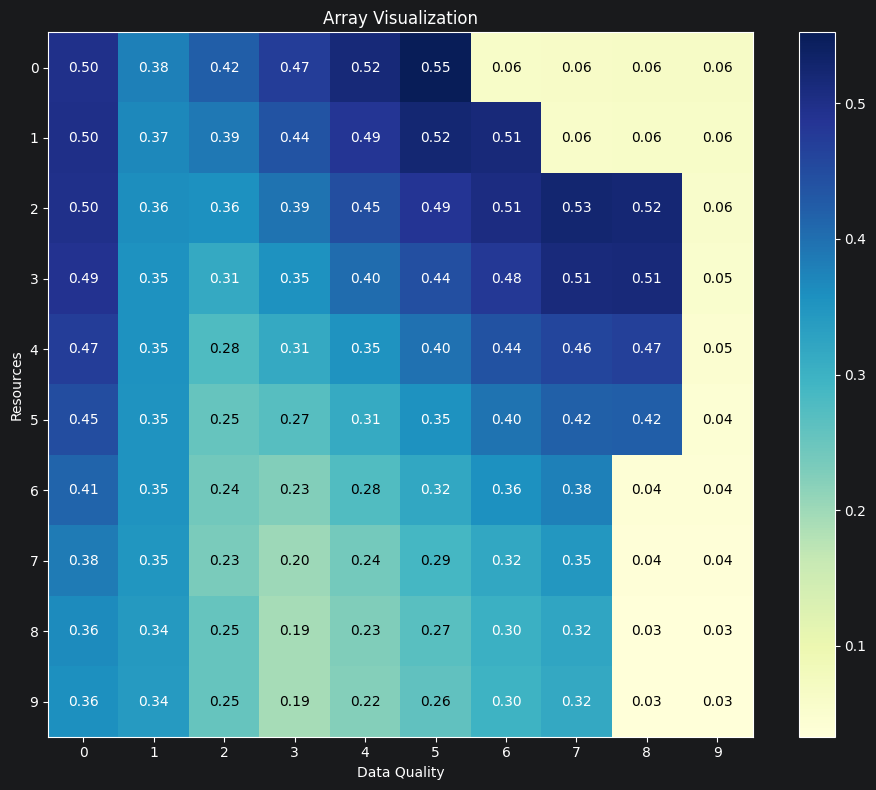

Versatile Candidate: {'coord': array([0.        , 0.63462089]), 'fitness': np.float64(0.5522922051357746)}
Versatile Candidate: {'coord': array([0.29796138, 0.87717883]), 'fitness': np.float64(0.5255281857120389)}
Versatile Candidate: {'coord': array([0.16854562, 0.        ]), 'fitness': np.float64(0.49805354200502916)}
Versatile Candidate: {'coord': array([0.23599099, 0.65486811]), 'fitness': np.float64(0.4856365864658163)}
Versatile Candidate: {'coord': array([0.44621076, 0.        ]), 'fitness': np.float64(0.47305510758955294)}
Versatile Candidate: {'coord': array([0.1192904 , 0.43903925]), 'fitness': np.float64(0.43710356107517806)}
Versatile Candidate: {'coord': array([0.56064102, 0.89368416]), 'fitness': np.float64(0.4218709696388469)}
Versatile Candidate: {'coord': array([0.66945746, 0.01949838]), 'fitness': np.float64(0.4126564887313086)}
Versatile Candidate: {'coord': array([0.45842498, 0.65933609]), 'fitness': np.float64(0.3981129980478543)}
Versatile Candidate: {'coord': arr

In [12]:
extract_pfo_for_SLOs(slos_default)

Iteration 0: Elite found in bin (np.int64(4), np.int64(4)) with fitness 0.0588
Iteration 100: Elite found in bin (np.int64(0), np.int64(6)) with fitness 0.0086
Iteration 200: Elite found in bin (np.int64(4), np.int64(5)) with fitness 0.0621
Iteration 300: Elite found in bin (np.int64(8), np.int64(0)) with fitness 0.9015
Iteration 600: Elite found in bin (np.int64(1), np.int64(9)) with fitness 0.0091
Iteration 700: Elite found in bin (np.int64(2), np.int64(9)) with fitness 0.0085


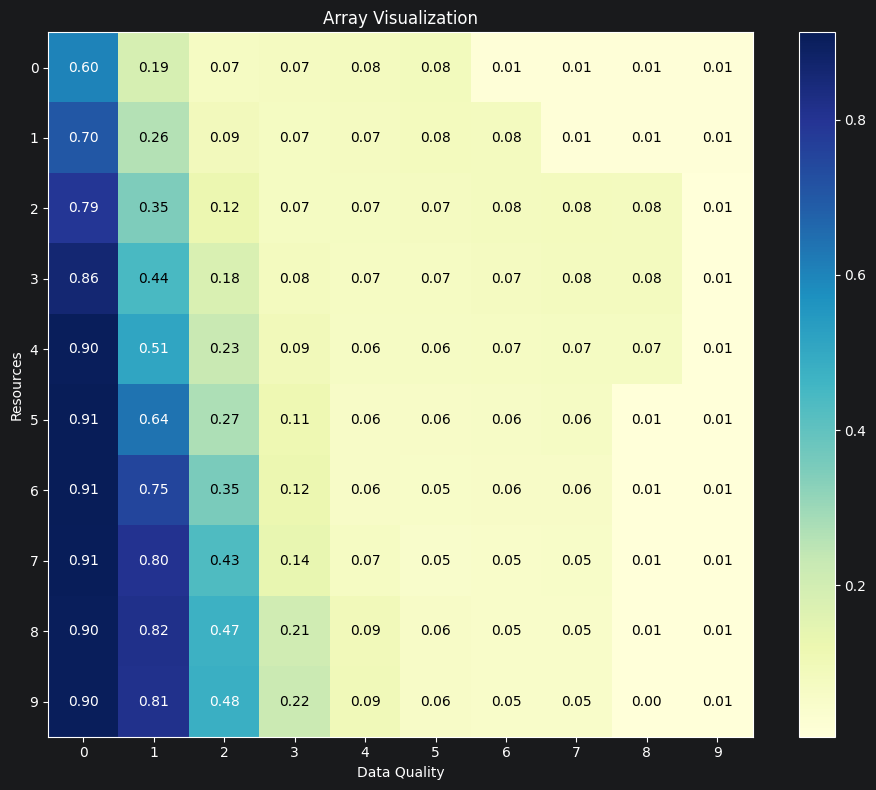

Versatile Candidate: {'coord': array([0.62682637, 0.        ]), 'fitness': np.float64(0.9125270565455832)}
Versatile Candidate: {'coord': array([0.89987257, 0.04278261]), 'fitness': np.float64(0.9035825958393741)}
Versatile Candidate: {'coord': array([0.32764086, 0.        ]), 'fitness': np.float64(0.7892556068576515)}
Versatile Candidate: {'coord': array([0.10476038, 0.        ]), 'fitness': np.float64(0.6011937634777245)}
Versatile Candidate: {'coord': array([1.        , 0.22837829]), 'fitness': np.float64(0.47741099844570994)}
Versatile Candidate: {'coord': array([0.7585444 , 0.22481708]), 'fitness': np.float64(0.35455365892416285)}
Versatile Candidate: {'coord': array([0.54644649, 0.23216525]), 'fitness': np.float64(0.2255064520044663)}
Versatile Candidate: {'coord': array([0.33022261, 0.23738243]), 'fitness': np.float64(0.11878867662756874)}
Versatile Candidate: {'coord': array([1.       , 0.4453729]), 'fitness': np.float64(0.094693665079161)}
Versatile Candidate: {'coord': array(

In [7]:
extract_pfo_for_SLOs(slos_high_perf)

Iteration 0: Elite found in bin (np.int64(8), np.int64(7)) with fitness 0.0626
Iteration 100: Elite found in bin (np.int64(0), np.int64(6)) with fitness 0.0862
Iteration 200: Elite found in bin (np.int64(7), np.int64(9)) with fitness 0.0090
Iteration 300: Elite found in bin (np.int64(1), np.int64(5)) with fitness 0.7546
Iteration 1600: Elite found in bin (np.int64(9), np.int64(1)) with fitness 0.0457
Iteration 2300: Elite found in bin (np.int64(3), np.int64(9)) with fitness 0.0561
Iteration 3200: Elite found in bin (np.int64(4), np.int64(6)) with fitness 0.4381


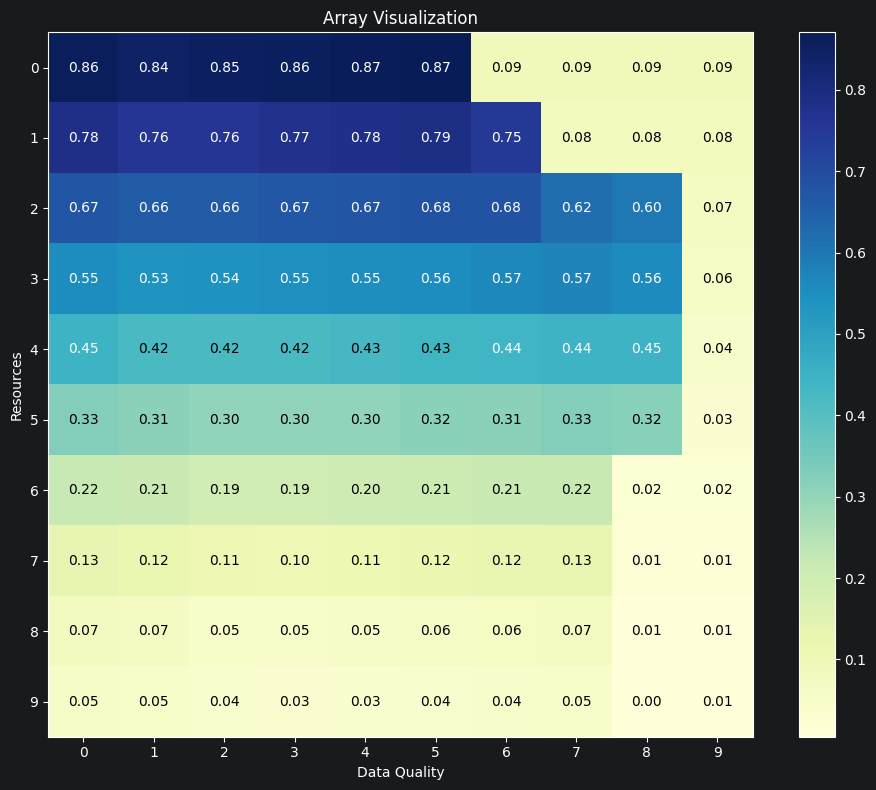

Versatile Candidate: {'coord': array([0.        , 0.63388297]), 'fitness': np.float64(0.8706738338193988)}
Versatile Candidate: {'coord': array([0., 0.]), 'fitness': np.float64(0.8605471088743296)}
Versatile Candidate: {'coord': array([0.        , 0.33039469]), 'fitness': np.float64(0.8509747787243778)}
Versatile Candidate: {'coord': array([0.22583378, 0.69359981]), 'fitness': np.float64(0.6811618404125571)}
Versatile Candidate: {'coord': array([0.22714995, 0.02473334]), 'fitness': np.float64(0.672781602829004)}
Versatile Candidate: {'coord': array([0.22284012, 0.43970343]), 'fitness': np.float64(0.6686898100306409)}
Versatile Candidate: {'coord': array([0.31197229, 0.8986508 ]), 'fitness': np.float64(0.5971536043515867)}
Versatile Candidate: {'coord': array([0.44516378, 0.00218985]), 'fitness': np.float64(0.44715975975528216)}
Versatile Candidate: {'coord': array([0.44928868, 0.74606417]), 'fitness': np.float64(0.43812035410219136)}
Versatile Candidate: {'coord': array([0.4490627 , 0.

In [8]:
extract_pfo_for_SLOs(slos_low_cost)

Iteration 0: Elite found in bin (np.int64(2), np.int64(5)) with fitness 0.5291
Iteration 700: Elite found in bin (np.int64(5), np.int64(0)) with fitness 0.3309
Iteration 1300: Elite found in bin (np.int64(2), np.int64(6)) with fitness 0.6133
Iteration 3500: Elite found in bin (np.int64(1), np.int64(1)) with fitness 0.1906


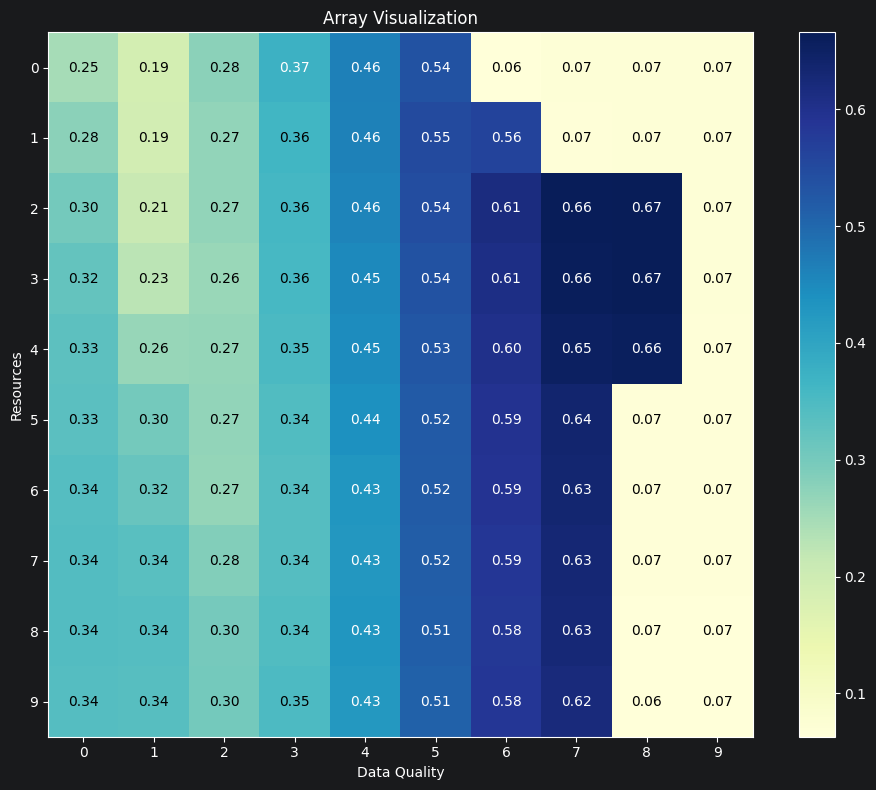

Versatile Candidate: {'coord': array([0.33134926, 0.90507183]), 'fitness': np.float64(0.6659077510838636)}
Versatile Candidate: {'coord': array([0.6187138 , 0.86735547]), 'fitness': np.float64(0.6365370991729331)}
Versatile Candidate: {'coord': array([0.88925023, 0.86923684]), 'fitness': np.float64(0.6264185237792219)}
Versatile Candidate: {'coord': array([0.20763294, 0.68558106]), 'fitness': np.float64(0.5604247512324073)}
Versatile Candidate: {'coord': array([0.47019082, 0.66095423]), 'fitness': np.float64(0.5273808780391293)}
Versatile Candidate: {'coord': array([0.67042687, 0.66260252]), 'fitness': np.float64(0.5176515200322314)}
Versatile Candidate: {'coord': array([0.97071242, 0.66590706]), 'fitness': np.float64(0.5129496958096177)}
Versatile Candidate: {'coord': array([0.        , 0.55108502]), 'fitness': np.float64(0.4647832820648146)}
Versatile Candidate: {'coord': array([0.27948598, 0.44120695]), 'fitness': np.float64(0.35873526047106435)}
Versatile Candidate: {'coord': array

In [9]:
extract_pfo_for_SLOs(slos_high_quality)